# Compute and analyze prediction metrics for hurricane track.
author: Elizabeth A. Barnes and Randal J. Barnes

In [1]:
import sys

sys.path.append("..")

import os

import cmasher as cmr
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from silence_tensorflow import silence_tensorflow

import experiment_settings
import prediction_metrics
from build_data import build_data

mpl.rcParams["figure.facecolor"] = "white"
np.warnings.filterwarnings("ignore", category=np.VisibleDeprecationWarning)
dpiFig = 300.0

In [2]:
__author__ = "Randal J Barnes and Elizabeth A. Barnes"
__version__ = "24 August 2022"

silence_tensorflow()
tf.config.set_visible_devices([], "GPU")  # turn-off tensorflow-metal if it is on

DATA_PATH = "../data/"
MODEL_PATH = "saved_models/"
METRIC_PATH = "saved_metrics/"
FIGURE_PATH = "figures/analysis/"
OVERWRITE_METRICS = False

In [3]:
EXP_NAME_LIST = (
    "centered_bivariate_normal_100_EPCP12",
    "centered_bivariate_normal_101_EPCP24",
    "centered_bivariate_normal_102_EPCP36",
    "centered_bivariate_normal_103_EPCP48",
)

# Get metrics

In [4]:
def get_metrics(model, x_data, onehot_data):

    y_data = model.predict(x_data)
    rmse, rmse_cons = prediction_metrics.get_errors(y_data, onehot_data)
    bins, pit_hist, D, EDp = prediction_metrics.compute_pit(y_data, onehot_data)
    nll = prediction_metrics.compute_nll(y_data, onehot_data)

    # write metrics dictionary and return
    metrics_dict = {
        "pit_D": D,
        "pit_EDp": EDp,
        "cons_error": rmse_cons.mean(),
        "mean_error": rmse.mean(),
        "mean_error_reduction": rmse_cons.mean() - rmse.mean(),
        "perc_error_reduction": 100.0
        * (rmse_cons.mean() - rmse.mean())
        / rmse_cons.mean(),
        "neg_log_like": nll.mean(),
    }

    return metrics_dict


def get_best_validation(df):

    print("**plotting only the best seed for validation error reductions**")
    idx = (
        df.groupby(["exp_name", "testing_years"], sort=False)[
            "mean_error_reduction_val"
        ].transform(max)
        == df["mean_error_reduction_val"]
    )

    return df[idx]

In [5]:
for EXP_NAME in EXP_NAME_LIST:
    print("----" + EXP_NAME + "----")
    settings = experiment_settings.get_settings(EXP_NAME)

    for testing_years in np.arange(2013, 2022):
        settings["years_test"] = (testing_years,)

        for RNG_SEED in (1, 2, 3):
            network_seed = RNG_SEED
            settings["rng_seed"] = RNG_SEED

            # get model name
            model_name = (
                EXP_NAME
                + "_"
                + str(testing_years)
                + "_"
                + settings["uncertainty_type"]
                + "_"
                + f"rng_seed_{settings['rng_seed']}"
            )

            # check if metrics exist
            metric_filename = METRIC_PATH + model_name + "_metrics.pickle"
            if os.path.exists(metric_filename) and OVERWRITE_METRICS == False:
                # print(metric_filename + ' exists. Skipping...')
                continue

            # get the data
            (
                data_summary,
                x_train,
                onehot_train,
                x_val,
                onehot_val,
                x_test,
                onehot_test,
                x_valtest,
                onehot_valtest,
                df_train,
                df_val,
                df_test,
                df_valtest,
            ) = build_data(DATA_PATH, settings, verbose=0)

            # load the model
            try:
                model = tf.keras.models.load_model(
                    MODEL_PATH + model_name + "_model", compile=False
                )
            except Exception:
                break

            # make the predictions and put into dictionary
            metrics_test = get_metrics(model, x_test, onehot_test)
            metrics_val = get_metrics(model, x_val, onehot_val)
            metrics_valtest = get_metrics(model, x_valtest, onehot_valtest)
            metrics_train = get_metrics(model, x_train, onehot_train)

            # create the metrics dataframe
            d = dict()
            d["uncertainty_type"] = settings["uncertainty_type"]
            d["network_seed"] = network_seed
            d["rng_seed"] = settings["rng_seed"]
            d["exp_name"] = EXP_NAME
            d["basin_lead"] = EXP_NAME[EXP_NAME.rfind("_") + 1 :]
            d["testing_years"] = settings["years_test"][0]

            for k in metrics_test.keys():
                k_key = k + "_test"
                d[k_key] = metrics_test[k]
            for k in metrics_val.keys():
                k_key = k + "_val"
                d[k_key] = metrics_val[k]
            for k in metrics_valtest.keys():
                k_key = k + "_valtest"
                d[k_key] = metrics_valtest[k]
            for k in metrics_train.keys():
                k_key = k + "_train"
                d[k_key] = metrics_train[k]

            # save the dataframe
            # pprint.pprint(d, width=80)
            df = pd.DataFrame(data=d, index=[0])
            df.to_pickle(metric_filename)

----centered_bivariate_normal_100_EPCP12----
----centered_bivariate_normal_101_EPCP24----
----centered_bivariate_normal_102_EPCP36----
----centered_bivariate_normal_103_EPCP48----


# Plot metric results

In [6]:
# error("here")

In [7]:
N_COLORS = 50
colors = ("#D95980", "#284E60", "#284E60", "#C3B1E1", "#351F27", "#A9C961")

### for white background...
plt.rc("text", usetex=True)
plt.rc("font", **{"family": "sans-serif", "sans-serif": ["Avant Garde"]})
plt.rc("savefig", facecolor="white")
plt.rc("axes", facecolor="white")
plt.rc("axes", labelcolor="dimgrey")
plt.rc("axes", labelcolor="dimgrey")
plt.rc("xtick", color="dimgrey")
plt.rc("ytick", color="dimgrey")
################################
################################
def adjust_spines(ax, spines):
    for loc, spine in ax.spines.items():
        if loc in spines:
            spine.set_position(("outward", 5))
        else:
            spine.set_color("none")
    if "left" in spines:
        ax.yaxis.set_ticks_position("left")
    else:
        ax.yaxis.set_ticks([])
    if "bottom" in spines:
        ax.xaxis.set_ticks_position("bottom")
    else:
        ax.xaxis.set_ticks([])


def format_spines(ax):
    adjust_spines(ax, ["left", "bottom"])
    ax.spines["top"].set_color("none")
    ax.spines["right"].set_color("none")
    ax.spines["left"].set_color("dimgrey")
    ax.spines["bottom"].set_color("dimgrey")
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)
    ax.tick_params("both", length=4, width=2, which="major", color="dimgrey")


#     ax.yaxis.grid(zorder=1,color='dimgrey',alpha=0.35)

In [8]:
df_metrics = pd.DataFrame()


for EXP_NAME in EXP_NAME_LIST:

    for TESTING_YEAR in np.arange(2013, 2022):

        for RNG_SEED in (1, 2, 3):
            settings = experiment_settings.get_settings(EXP_NAME)

            settings["rng_seed"] = RNG_SEED
            settings["years_test"] = (TESTING_YEAR,)

            # check if metrics exist
            model_name = (
                EXP_NAME
                + "_"
                + str(TESTING_YEAR)
                + "_"
                + settings["uncertainty_type"]
                + "_"
                + f"rng_seed_{settings['rng_seed']}"
            )

            metric_filename = METRIC_PATH + model_name + "_metrics.pickle"
            if not os.path.exists(metric_filename):
                continue

            # build dataframe
            df = pd.read_pickle(metric_filename)
            df_metrics = pd.concat([df_metrics, df])

# df_metrics = df_metrics.reset_index()

BEST_VAL = True
if BEST_VAL:
    df_metrics = get_best_validation(df_metrics)

**plotting only the best seed for validation error reductions**


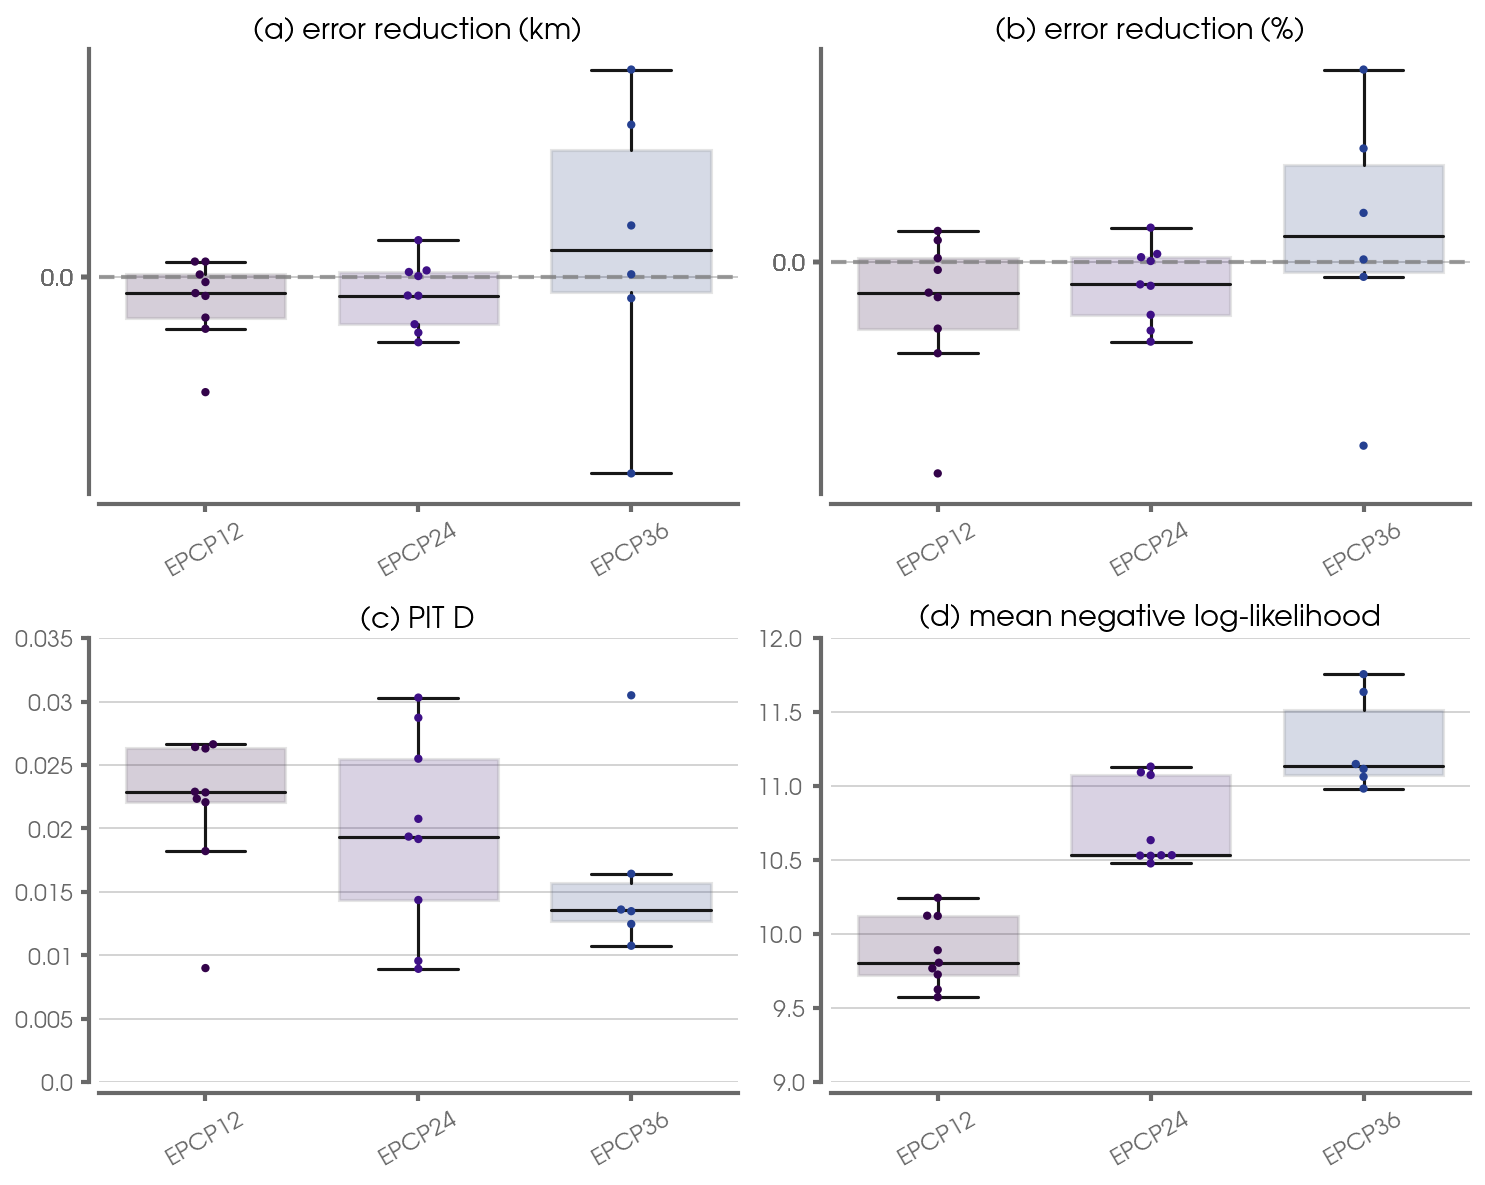

In [9]:
FS = 14

colors = cmr.take_cmap_colors(
    "cmr.rainforest", 10, cmap_range=(0.15, 0.85), return_fmt="hex"
)
# plt.get_cmap('cmr.rainforest')#('#D95980','#A9C961','#C3B1E1','#C3B1E1','#351F27')
panel_letters = ("(a)", "(b)", "(c)", "(d)")
x_axis_list = ("basin_lead",)  # ("basin_lead", "exp_name")

metric_data = ""
metric_list = (
    "mean_error_reduction_test",
    "perc_error_reduction_test",
    "pit_D_valtest",
    "neg_log_like_test",
)
title_text = (
    "(a) error reduction (km)",
    "(b) error reduction (\%)",
    "(c) PIT D",
    "(d) mean negative log-likelihood",
)

for x_axis in x_axis_list:
    f, axs = plt.subplots(2, 2, figsize=(10, 8), dpi=150)
    axs = axs.flatten()

    for imetric, metric in enumerate(metric_list):
        ax = axs[imetric]
        g1 = sns.boxplot(
            x=x_axis,
            y=metric,
            # hue="uncertainty_type",
            data=df_metrics,
            palette=colors,
            width=0.75,
            dodge=True,
            boxprops={
                "alpha": 0.2,
                "edgecolor": "gray",
            },
            fliersize=0,
            ax=ax,
        )
        g2 = sns.swarmplot(
            x=x_axis,
            y=metric,
            # hue="uncertainty_type",
            palette=colors,
            data=df_metrics,
            size=4,
            dodge=True,
            ax=ax,
        )

        # ax.get_legend().remove()
        ax.set_title(
            title_text[imetric],
            fontsize=FS,
            color="k",
        )

        if metric.find("pit_D") > -1:
            ax.set_ylim(0, None)
        if metric.find("reduction") > -1:
            ax.axhline(y=0.0, linewidth=2, linestyle="--", color="gray", alpha=0.75)

        x_tick_labels = ax.get_xticklabels()
        y_tick_labels = ax.get_yticklabels()
        yticks = np.around(ax.get_yticks(), 3)

        format_spines(ax)
        ax.set_xticklabels(x_tick_labels, rotation=30, fontsize=FS * 0.8)
        ax.set_xlabel("")
        ax.set_yticks(yticks)
        ax.set_yticklabels(yticks, fontsize=FS * 0.8)
        ax.set_ylabel("")

    plt.tight_layout()
    plt.savefig(
        FIGURE_PATH + "all_metrics_boxplots.png", dpi=dpiFig, bbox_inches="tight"
    )
    plt.show()

    print('**** THIS MUST BE WRONG!!!! **** The error reduction should be zero.')

In [10]:
df_metrics[df_metrics["basin_lead"] == "EPCP24"]

,uncertainty_type,network_seed,rng_seed,exp_name,basin_lead,testing_years,pit_D_test,pit_EDp_test,cons_error_test,mean_error_test,...,mean_error_reduction_valtest,perc_error_reduction_valtest,neg_log_like_valtest,pit_D_train,pit_EDp_train,cons_error_train,mean_error_train,mean_error_reduction_train,perc_error_reduction_train,neg_log_like_train
0,centered_bivariate_normal,1,1,centered_bivariate_normal_101_EPCP24,EPCP24,2013,0.033028,0.020135,73.777512,73.777512,...,-4.648752e-06,-6.627364e-06,10.907005,0.011515,0.006108,63.196136,63.196134,2.615399e-06,4.138543e-06,10.634774
0,centered_bivariate_normal,2,2,centered_bivariate_normal_101_EPCP24,EPCP24,2014,0.025784,0.015390,58.318310,58.318310,...,2.027248e-06,3.354947e-06,10.574980,0.007130,0.006319,65.209991,65.209987,4.581694e-06,7.026061e-06,10.626082
0,centered_bivariate_normal,1,1,centered_bivariate_normal_101_EPCP24,EPCP24,2015,0.038838,0.013019,76.320648,76.320647,...,1.782395e-07,2.458296e-07,10.986248,0.005108,0.006542,61.354633,61.354635,-1.867856e-06,-3.044361e-06,10.530666
0,centered_bivariate_normal,3,3,centered_bivariate_normal_101_EPCP24,EPCP24,2016,0.038107,0.015900,55.293999,55.294000,...,2.572567e-07,4.389089e-07,10.583491,0.012839,0.006286,65.602058,65.602055,3.687314e-06,5.620730e-06,10.724710
0,centered_bivariate_normal,2,2,centered_bivariate_normal_101_EPCP24,EPCP24,2017,0.025336,0.019570,57.691563,57.691565,...,3.985756e-06,6.543818e-06,10.591000,0.004747,0.006125,64.833221,64.833218,3.719164e-06,5.736510e-06,10.626195
0,centered_bivariate_normal,3,3,centered_bivariate_normal_101_EPCP24,EPCP24,2018,0.010429,0.013750,59.284492,59.284493,...,-1.051486e-06,-1.729383e-06,10.585832,0.008250,0.006458,65.305161,65.305160,3.846598e-08,5.890191e-08,10.655681
0,centered_bivariate_normal,2,2,centered_bivariate_normal_101_EPCP24,EPCP24,2019,0.042409,0.020000,74.518318,74.518318,...,5.938298e-06,8.596199e-06,10.880633,0.004391,0.006112,63.375248,63.375248,-1.411955e-07,-2.227928e-07,10.594516
0,centered_bivariate_normal,2,2,centered_bivariate_normal_101_EPCP24,EPCP24,2020,0.021419,0.022678,63.501263,63.501265,...,-1.307758e-06,-2.062363e-06,10.645969,0.007591,0.006050,64.355911,64.355915,-3.411377e-06,-5.300798e-06,10.623093
0,centered_bivariate_normal,2,2,centered_bivariate_normal_101_EPCP24,EPCP24,2021,0.032892,0.019612,58.219711,58.219714,...,-1.010488e-06,-1.673932e-06,10.566881,0.006450,0.006124,64.929703,64.929704,-8.545065e-07,-1.316049e-06,10.620746


In [11]:
df_metrics

,uncertainty_type,network_seed,rng_seed,exp_name,basin_lead,testing_years,pit_D_test,pit_EDp_test,cons_error_test,mean_error_test,...,mean_error_reduction_valtest,perc_error_reduction_valtest,neg_log_like_valtest,pit_D_train,pit_EDp_train,cons_error_train,mean_error_train,mean_error_reduction_train,perc_error_reduction_train,neg_log_like_train
0,centered_bivariate_normal,1,1,centered_bivariate_normal_100_EPCP12,EPCP12,2013,0.030481,0.018570,45.877995,45.877994,...,-5.172453e-06,-1.171237e-05,9.997588,0.017839,0.005720,41.357723,41.357724,-8.624889e-07,-2.085436e-06,9.804766
0,centered_bivariate_normal,2,2,centered_bivariate_normal_100_EPCP12,EPCP12,2014,0.027977,0.014535,38.722023,38.722028,...,-1.222584e-06,-3.063989e-06,9.822109,0.012517,0.005899,42.210155,42.210154,1.883090e-06,4.461226e-06,9.814161
0,centered_bivariate_normal,3,3,centered_bivariate_normal_100_EPCP12,EPCP12,2015,0.024024,0.012414,50.447334,50.447334,...,2.418088e-06,5.151083e-06,10.104337,0.013856,0.006088,40.086647,40.086651,-3.605802e-06,-8.995020e-06,9.748160
0,centered_bivariate_normal,2,2,centered_bivariate_normal_100_EPCP12,EPCP12,2016,0.033795,0.015057,35.189247,35.189246,...,-3.291968e-06,-8.656521e-06,9.697713,0.014479,0.005867,42.612141,42.612144,-2.899871e-06,-6.805269e-06,9.850884
0,centered_bivariate_normal,1,1,centered_bivariate_normal_100_EPCP12,EPCP12,2017,0.032188,0.018224,38.288254,38.288255,...,-1.827704e-06,-4.616053e-06,9.760099,0.016213,0.005730,42.132401,42.132399,1.708462e-06,4.054984e-06,9.839851
0,centered_bivariate_normal,1,1,centered_bivariate_normal_100_EPCP12,EPCP12,2018,0.032568,0.013106,37.434040,37.434041,...,-2.154088e-06,-5.488938e-06,9.710498,0.023050,0.006014,42.492424,42.492423,1.463868e-06,3.445010e-06,9.868639
0,centered_bivariate_normal,1,1,centered_bivariate_normal_100_EPCP12,EPCP12,2019,0.040023,0.018464,45.621235,45.621235,...,1.477207e-06,3.313882e-06,10.023056,0.016452,0.005723,41.284760,41.284758,1.552319e-06,3.760029e-06,9.803338
0,centered_bivariate_normal,1,1,centered_bivariate_normal_100_EPCP12,EPCP12,2020,0.013809,0.020653,43.320354,43.320356,...,8.882127e-07,2.081987e-06,9.853575,0.013568,0.005668,41.627968,41.627968,3.189984e-07,7.663078e-07,9.809290
0,centered_bivariate_normal,2,2,centered_bivariate_normal_100_EPCP12,EPCP12,2021,0.026928,0.018124,40.352768,40.352770,...,1.013901e-06,2.436062e-06,9.835404,0.013041,0.005733,41.784447,41.784444,2.794764e-06,6.688528e-06,9.812540
0,centered_bivariate_normal,1,1,centered_bivariate_normal_101_EPCP24,EPCP24,2013,0.033028,0.020135,73.777512,73.777512,...,-4.648752e-06,-6.627364e-06,10.907005,0.011515,0.006108,63.196136,63.196134,2.615399e-06,4.138543e-06,10.634774
